# Notebook 2 — Exercises 2 & 3: Handwritten Digit Classification

> **Story context:** CompanyX's distribution process involves manually entered data that gets scanned. They want a system to automatically recognize handwritten digits (0–9) to accelerate digitization.
>
> In Exercise 1 we built a single perceptron — one neuron, one nonlinearity. That was enough to approximate a scalar fraud probability. But classifying 10 different digit classes is a fundamentally different, non-linearly separable problem. Just as XOR required an MLP (Notebook 0), so does this.

**Exercise 2:** First attempt with `digits.csv`. Explore architectures, learning rates, and optimization variants.  
**Exercise 3:** CompanyX asks for ≥98% accuracy. New data (`more_data_digits.csv`) available. Push the limits.

**Roadmap:**
1. Load and explore both datasets
2. Scale the MLP implementation for image data
3. Systematic experiment: learning rate, architecture, optimization
4. Evaluate on test set
5. Add more data (Ex. 3) and push to 98%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
import os

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

---
## Part 1 — Data Loading & EDA

In [2]:
import ast

df_train = pd.read_csv('TP3---Percepetron-Simple-y-Multi-Capa/data_and_docs/digits.csv')
df_test  = pd.read_csv('TP3---Percepetron-Simple-y-Multi-Capa/data_and_docs/digits_test.csv')

print(f"Train shape : {df_train.shape}")
print(f"Test  shape : {df_test.shape}")

# 'image' column is stored as a string list — parse it into a 2D array
X_train = np.array([ast.literal_eval(img) for img in df_train['image']], dtype=float)
y_train = df_train['label'].values.astype(int)
X_test  = np.array([ast.literal_eval(img) for img in df_test['image']], dtype=float)
y_test  = df_test['label'].values.astype(int)

n_features = X_train.shape[1]
n_classes  = 10
print(f"\nFeatures (pixels): {n_features}  →  image size: {int(n_features**0.5)}x{int(n_features**0.5)}")
print(f"Classes: {np.unique(y_train)}")
print(f"\nTrain class distribution:")
for c in range(n_classes):
    print(f"  Digit {c}: {(y_train==c).sum()} samples")

Train shape : (12449, 2)
Test  shape : (2497, 2)

Features (pixels): 784  →  image size: 28x28
Classes: [0 1 2 3 4 5 6 7 9]

Train class distribution:
  Digit 0: 1480 samples
  Digit 1: 1685 samples
  Digit 2: 1489 samples
  Digit 3: 1532 samples
  Digit 4: 1460 samples
  Digit 5: 271 samples
  Digit 6: 1479 samples
  Digit 7: 1566 samples
  Digit 8: 0 samples
  Digit 9: 1487 samples


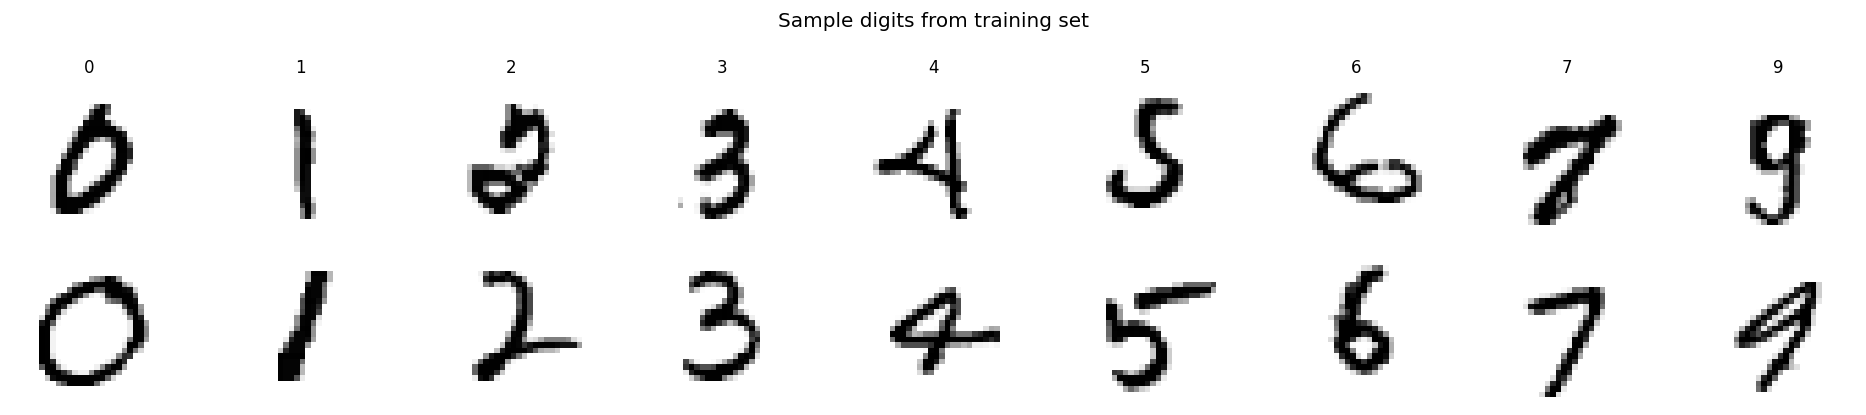

Pixel value range: [0.0, 1.0]


In [3]:
# Visualize sample digits
img_size      = int(n_features ** 0.5)
unique_digits = np.unique(y_train)
n_digits      = len(unique_digits)

fig, axes = plt.subplots(2, n_digits, figsize=(16, 3.5))
for i, digit in enumerate(unique_digits):
    indices = np.where(y_train == digit)[0]
    axes[0, i].imshow(X_train[indices[0]].reshape(img_size, img_size),
                      cmap='gray_r', interpolation='nearest')
    axes[0, i].set_title(str(digit), fontsize=10)
    axes[0, i].axis('off')
    idx2 = indices[1] if len(indices) > 1 else indices[0]
    axes[1, i].imshow(X_train[idx2].reshape(img_size, img_size),
                      cmap='gray_r', interpolation='nearest')
    axes[1, i].axis('off')

plt.suptitle('Sample digits from training set', fontsize=12)
plt.tight_layout()
plt.savefig('ex2_sample_digits.png', bbox_inches='tight')
plt.show()

print(f"Pixel value range: [{X_train.min():.1f}, {X_train.max():.1f}]")

---
## Part 2 — MLP Implementation (Production-Grade)

We extend the MLP from Notebook 0 with:
- **Vectorized forward/backward pass** (matrix operations over mini-batches)
- **Mini-batch gradient descent** (faster than pure online learning)
- **Momentum** (optional — reduces oscillations)
- **Softmax output layer** for proper probability distributions over 10 classes
- **Cross-entropy loss** (appropriate for classification, unlike SSE)
- **Model save/load** for resuming long experiments
- **Per-epoch accuracy tracking**

### Why Softmax + Cross-Entropy?
For 10-class classification, the output layer should produce a probability distribution over the 10 digits. **Softmax** ensures all outputs sum to 1:
$$p_i = \frac{e^{h_i}}{\sum_j e^{h_j}}$$

**Cross-entropy** penalizes confident wrong predictions more than SSE:
$$\mathcal{L} = -\sum_i \zeta_i \log(p_i)$$

The combined gradient of softmax + cross-entropy is elegantly simple: $\delta_i = p_i - \zeta_i$.

In [4]:
def softmax(h):
    """Numerically stable softmax over last axis."""
    e = np.exp(h - h.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def one_hot(y, n_classes):
    """Convert integer labels to one-hot encoding."""
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1
    return oh


class MLPClassifier:
    """
    Multilayer Perceptron for multi-class classification.

    Architecture:
      - Hidden layers: tanh activation
      - Output layer: softmax
      - Loss: cross-entropy

    Optimization:
      - Mini-batch gradient descent
      - Optional momentum
      - Optional learning rate decay

    Parameters:
      architecture : list of ints, e.g. [64, 32, 10]
                     First = input features, Last = n_classes
      learning_rate: float
      momentum     : float in [0, 1). 0 = no momentum (SGD)
      batch_size   : int. Use len(X) for full-batch gradient descent.
      max_epochs   : int
      lr_decay     : float. Multiply lr by this every epoch. 1.0 = no decay.
      beta         : float. Tanh steepness.
    """

    def __init__(self, architecture, learning_rate=0.01, momentum=0.0,
                 batch_size=32, max_epochs=100, lr_decay=1.0, beta=1.0):
        self.arch         = architecture
        self.lr0          = learning_rate
        self.lr           = learning_rate
        self.momentum     = momentum
        self.batch_size   = batch_size
        self.max_epochs   = max_epochs
        self.lr_decay     = lr_decay
        self.beta         = beta
        self.n_layers     = len(architecture) - 1
        self.n_classes    = architecture[-1]

        # He initialization for tanh layers (better than uniform for deep nets)
        self.W = []
        self.b = []
        for l in range(self.n_layers):
            fan_in = architecture[l]
            std = np.sqrt(2.0 / fan_in)  # He init
            self.W.append(np.random.randn(architecture[l+1], architecture[l]) * std)
            self.b.append(np.zeros(architecture[l+1]))

        # Momentum buffers (same shape as W, b)
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]

        # Training history
        self.train_loss     = []
        self.train_accuracy = []
        self.val_accuracy   = []
        self.epoch          = 0
        self.config         = {}  # store hyperparameters for logging

    # ── Activations ───────────────────────────────────────────────────────────

    def _g(self, h):    return np.tanh(self.beta * h)
    def _gp(self, a):   return self.beta * (1 - a**2)

    # ── Forward pass (batched) ────────────────────────────────────────────────

    def _forward(self, X):
        """
        X: (batch, n_features)
        Returns:
          activations : list of activation arrays per layer (including input)
          pre_acts    : list of pre-activation h arrays per layer
        """
        activations = [X]
        pre_acts    = []
        a = X
        for l in range(self.n_layers):
            h = a @ self.W[l].T + self.b[l]  # (batch, arch[l+1])
            pre_acts.append(h)
            if l < self.n_layers - 1:
                a = self._g(h)                # tanh for hidden layers
            else:
                a = softmax(h)                # softmax for output
            activations.append(a)
        return activations, pre_acts

    def predict_proba(self, X):
        activations, _ = self._forward(X)
        return activations[-1]

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    # ── Backward pass (batched) ───────────────────────────────────────────────

    def _backward(self, X_batch, y_batch_oh):
        """
        Returns gradient lists dW, db averaged over the batch.
        y_batch_oh: one-hot encoded targets (batch, n_classes)
        """
        bsz = X_batch.shape[0]
        activations, pre_acts = self._forward(X_batch)

        dW = [None] * self.n_layers
        db = [None] * self.n_layers

        # Output layer: softmax + cross-entropy gradient is (p - y)
        delta = activations[-1] - y_batch_oh  # (batch, n_classes)

        for l in range(self.n_layers - 1, -1, -1):
            dW[l] = (delta.T @ activations[l]) / bsz
            db[l] = delta.mean(axis=0)
            if l > 0:
                # Propagate delta to previous layer
                delta = (delta @ self.W[l]) * self._gp(activations[l])

        return dW, db

    # ── Training loop ─────────────────────────────────────────────────────────

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        n = X.shape[0]
        n_classes = self.n_classes
        y_oh = one_hot(y, n_classes)

        for epoch in range(self.max_epochs):
            t0 = time.time()
            # Shuffle
            perm = np.random.permutation(n)
            X_s, y_s, y_oh_s = X[perm], y[perm], y_oh[perm]

            # Mini-batch updates
            epoch_loss = 0.0
            n_batches  = 0
            for start in range(0, n, self.batch_size):
                Xb = X_s[start:start+self.batch_size]
                yb = y_oh_s[start:start+self.batch_size]
                dW, db = self._backward(Xb, yb)

                # Momentum update
                for l in range(self.n_layers):
                    self.vW[l] = self.momentum * self.vW[l] - self.lr * dW[l]
                    self.vb[l] = self.momentum * self.vb[l] - self.lr * db[l]
                    self.W[l] += self.vW[l]
                    self.b[l] += self.vb[l]

                # Cross-entropy loss for this batch
                proba = self.predict_proba(Xb)
                ce = -np.mean(np.sum(yb * np.log(proba + 1e-12), axis=1))
                epoch_loss += ce
                n_batches  += 1

            # Learning rate decay
            self.lr *= self.lr_decay

            # Metrics
            avg_loss    = epoch_loss / n_batches
            train_acc   = np.mean(self.predict(X) == y)
            self.train_loss.append(avg_loss)
            self.train_accuracy.append(train_acc)

            val_acc = None
            if X_val is not None:
                val_acc = np.mean(self.predict(X_val) == y_val)
                self.val_accuracy.append(val_acc)

            self.epoch += 1
            elapsed = time.time() - t0

            if verbose:
                msg = (f"  Epoch {self.epoch:3d}/{self.max_epochs} "
                       f"| Loss={avg_loss:.4f} | Train={train_acc:.4f}")
                if val_acc is not None:
                    msg += f" | Val={val_acc:.4f}"
                msg += f" | {elapsed:.1f}s"
                print(msg)

        return self

    # ── Save / Load ───────────────────────────────────────────────────────────

    def save(self, path):
        """Save weights and config to a .npz file."""
        data = {
            'arch':          np.array(self.arch),
            'lr':            self.lr,
            'lr0':           self.lr0,
            'momentum':      self.momentum,
            'batch_size':    self.batch_size,
            'max_epochs':    self.max_epochs,
            'lr_decay':      self.lr_decay,
            'beta':          self.beta,
            'epoch':         self.epoch,
            'train_loss':    np.array(self.train_loss),
            'train_accuracy':np.array(self.train_accuracy),
            'val_accuracy':  np.array(self.val_accuracy),
        }
        for l, (w, b) in enumerate(zip(self.W, self.b)):
            data[f'W_{l}'] = w
            data[f'b_{l}'] = b
        np.savez(path, **data)
        print(f"  Model saved to {path}.npz")

    @classmethod
    def load(cls, path):
        """Load a saved model."""
        d = np.load(path + '.npz', allow_pickle=True)
        arch = d['arch'].tolist()
        model = cls(
            architecture=arch,
            learning_rate=float(d['lr0']),
            momentum=float(d['momentum']),
            batch_size=int(d['batch_size']),
            max_epochs=int(d['max_epochs']),
            lr_decay=float(d['lr_decay']),
            beta=float(d['beta']),
        )
        n_layers = len(arch) - 1
        model.W = [d[f'W_{l}'] for l in range(n_layers)]
        model.b = [d[f'b_{l}'] for l in range(n_layers)]
        model.epoch          = int(d['epoch'])
        model.lr             = float(d['lr'])
        model.train_loss     = d['train_loss'].tolist()
        model.train_accuracy = d['train_accuracy'].tolist()
        model.val_accuracy   = d['val_accuracy'].tolist()
        print(f"  Model loaded from {path}.npz (epoch {model.epoch})")
        return model

print("MLPClassifier ready.")

MLPClassifier ready.


---
## Part 3 — Data Preprocessing

In [5]:
# Normalize pixel values to [0, 1] using training set statistics
# Pixels are typically in [0, 255] or [0, 16] depending on the dataset
x_min = X_train.min(axis=0)
x_max = X_train.max(axis=0)
x_range = np.where(x_max - x_min > 0, x_max - x_min, 1.0)  # avoid div by zero

X_train_n = (X_train - x_min) / x_range
X_test_n  = (X_test  - x_min) / x_range  # use training stats!

print(f"Pixel range after normalization: [{X_train_n.min():.2f}, {X_train_n.max():.2f}]")

# Split training set into train/validation for hyperparameter tuning
# We keep the test set untouched until the final evaluation
np.random.seed(42)
perm = np.random.permutation(len(X_train_n))
val_size = int(0.15 * len(X_train_n))
val_idx, tr_idx = perm[:val_size], perm[val_size:]

X_tr, X_val = X_train_n[tr_idx], X_train_n[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print(f"Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test_n)} (untouched)")

Pixel range after normalization: [0.00, 1.00]
Train: 10582 | Val: 1867 | Test: 2497 (untouched)


---
## Part 4 — Exercise 2: Systematic Hyperparameter Study

We run a structured grid of experiments and log results to compare systematically.  
We vary:
1. **Learning rate** (most impactful hyperparameter)
2. **Architecture** (depth and width of hidden layers)
3. **Optimization mechanism** (vanilla SGD, momentum, learning rate decay)

Each experiment is logged so we can compare without re-running.

In [6]:
# ── Experiment logger ─────────────────────────────────────────────────────────

EXPERIMENT_LOG = []  # in-memory log, extend as experiments run

def run_experiment(name, architecture, learning_rate, momentum=0.0,
                   lr_decay=1.0, batch_size=32, max_epochs=50,
                   X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val,
                   verbose=False, save_model=False):
    """Train one MLP configuration and log results."""
    print(f"Running: {name}")
    t0 = time.time()

    model = MLPClassifier(
        architecture=architecture,
        learning_rate=learning_rate,
        momentum=momentum,
        lr_decay=lr_decay,
        batch_size=batch_size,
        max_epochs=max_epochs,
    )
    model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val, verbose=verbose)

    final_train = model.train_accuracy[-1]
    final_val   = model.val_accuracy[-1] if model.val_accuracy else None
    elapsed     = time.time() - t0

    entry = {
        'name':         name,
        'architecture': architecture,
        'lr':           learning_rate,
        'momentum':     momentum,
        'lr_decay':     lr_decay,
        'batch_size':   batch_size,
        'max_epochs':   max_epochs,
        'train_acc':    round(final_train, 4),
        'val_acc':      round(final_val, 4) if final_val else None,
        'time_s':       round(elapsed, 1),
        'model':        model,
    }
    EXPERIMENT_LOG.append(entry)

    print(f"  Train={final_train:.4f} | Val={final_val:.4f} | {elapsed:.0f}s")
    if save_model:
        model.save(f'model_{name.replace(" ","_")}')
    return model

In [7]:
# ── 4.1 Learning rate study ───────────────────────────────────────────────────
# Keep architecture and optimizer fixed, vary lr only.
# Hypothesis: too small → slow convergence; too large → diverges.

BASE_ARCH = [n_features, 64, n_classes]  # [input, 1 hidden layer, output]

for lr in [0.1, 0.01, 0.001, 0.0001]:
    run_experiment(
        name=f"lr={lr}",
        architecture=BASE_ARCH,
        learning_rate=lr,
        max_epochs=50,
    )
print("\nLearning rate study done.")

Running: lr=0.1
  Train=1.0000 | Val=0.9561 | 21s
Running: lr=0.01
  Train=0.9663 | Val=0.9427 | 23s
Running: lr=0.001
  Train=0.9178 | Val=0.9041 | 21s
Running: lr=0.0001
  Train=0.8122 | Val=0.8163 | 18s

Learning rate study done.


In [8]:
# ── 4.2 Architecture study ────────────────────────────────────────────────────
# Fix the best lr from above, vary depth and width.

# Pick best lr from experiment log
lr_exps = [e for e in EXPERIMENT_LOG if e['name'].startswith('lr=')]
best_lr_entry = max(lr_exps, key=lambda e: e['val_acc'] or 0)
BEST_LR = best_lr_entry['lr']
print(f"Best lr from grid: {BEST_LR} (val_acc={best_lr_entry['val_acc']})\n")

architectures = {
    'shallow-32':    [n_features, 32, n_classes],
    'shallow-64':    [n_features, 64, n_classes],
    'shallow-128':   [n_features, 128, n_classes],
    'deep-64-32':    [n_features, 64, 32, n_classes],
    'deep-128-64':   [n_features, 128, 64, n_classes],
    'deep-3layers':  [n_features, 128, 64, 32, n_classes],
}

for arch_name, arch in architectures.items():
    run_experiment(
        name=f"arch-{arch_name}",
        architecture=arch,
        learning_rate=BEST_LR,
        max_epochs=50,
    )
print("\nArchitecture study done.")

Best lr from grid: 0.1 (val_acc=0.9561)

Running: arch-shallow-32
  Train=0.9995 | Val=0.9534 | 13s
Running: arch-shallow-64
  Train=0.9999 | Val=0.9582 | 18s
Running: arch-shallow-128
  Train=1.0000 | Val=0.9625 | 37s
Running: arch-deep-64-32
  Train=1.0000 | Val=0.9609 | 23s
Running: arch-deep-128-64
  Train=1.0000 | Val=0.9593 | 42s
Running: arch-deep-3layers
  Train=1.0000 | Val=0.9668 | 45s

Architecture study done.


In [9]:
# ── 4.3 Optimization study ────────────────────────────────────────────────────
# Fix best lr + best arch, vary optimizer settings.

arch_exps = [e for e in EXPERIMENT_LOG if e['name'].startswith('arch-')]
best_arch_entry = max(arch_exps, key=lambda e: e['val_acc'] or 0)
BEST_ARCH = best_arch_entry['architecture']
print(f"Best arch: {BEST_ARCH} (val_acc={best_arch_entry['val_acc']})\n")

opt_configs = [
    {'name': 'sgd',             'momentum': 0.0,  'lr_decay': 1.0,   'batch_size': 32},
    {'name': 'momentum-0.9',    'momentum': 0.9,  'lr_decay': 1.0,   'batch_size': 32},
    {'name': 'momentum-0.95',   'momentum': 0.95, 'lr_decay': 1.0,   'batch_size': 32},
    {'name': 'lr-decay-0.99',   'momentum': 0.0,  'lr_decay': 0.99,  'batch_size': 32},
    {'name': 'momentum+decay',  'momentum': 0.9,  'lr_decay': 0.995, 'batch_size': 32},
    {'name': 'large-batch',     'momentum': 0.0,  'lr_decay': 1.0,   'batch_size': 128},
]

for cfg in opt_configs:
    run_experiment(
        name=f"opt-{cfg['name']}",
        architecture=BEST_ARCH,
        learning_rate=BEST_LR,
        momentum=cfg['momentum'],
        lr_decay=cfg['lr_decay'],
        batch_size=cfg['batch_size'],
        max_epochs=50,
    )
print("\nOptimization study done.")

Best arch: [784, 128, 64, 32, 10] (val_acc=0.9668)

Running: opt-sgd
  Train=1.0000 | Val=0.9566 | 47s
Running: opt-momentum-0.9
  Train=0.9745 | Val=0.9438 | 45s
Running: opt-momentum-0.95
  Train=0.1192 | Val=0.1221 | 44s
Running: opt-lr-decay-0.99
  Train=1.0000 | Val=0.9646 | 47s
Running: opt-momentum+decay
  Train=0.9999 | Val=0.9609 | 51s
Running: opt-large-batch
  Train=0.9999 | Val=0.9604 | 29s

Optimization study done.


In [10]:
# ── Results summary table ─────────────────────────────────────────────────────

df_results = pd.DataFrame([
    {'Experiment': e['name'], 'Architecture': str(e['architecture']),
     'LR': e['lr'], 'Momentum': e['momentum'], 'LR Decay': e['lr_decay'],
     'Train Acc': e['train_acc'], 'Val Acc': e['val_acc'], 'Time (s)': e['time_s']}
    for e in EXPERIMENT_LOG
])
print(df_results.sort_values('Val Acc', ascending=False).to_string(index=False))

        Experiment           Architecture     LR  Momentum  LR Decay  Train Acc  Val Acc  Time (s)
 arch-deep-3layers [784, 128, 64, 32, 10] 0.1000      0.00     1.000     1.0000   0.9668      44.7
 opt-lr-decay-0.99 [784, 128, 64, 32, 10] 0.1000      0.00     0.990     1.0000   0.9646      46.8
  arch-shallow-128         [784, 128, 10] 0.1000      0.00     1.000     1.0000   0.9625      36.6
   arch-deep-64-32      [784, 64, 32, 10] 0.1000      0.00     1.000     1.0000   0.9609      22.5
opt-momentum+decay [784, 128, 64, 32, 10] 0.1000      0.90     0.995     0.9999   0.9609      51.1
   opt-large-batch [784, 128, 64, 32, 10] 0.1000      0.00     1.000     0.9999   0.9604      29.3
  arch-deep-128-64     [784, 128, 64, 10] 0.1000      0.00     1.000     1.0000   0.9593      42.2
   arch-shallow-64          [784, 64, 10] 0.1000      0.00     1.000     0.9999   0.9582      18.3
           opt-sgd [784, 128, 64, 32, 10] 0.1000      0.00     1.000     1.0000   0.9566      46.6
          

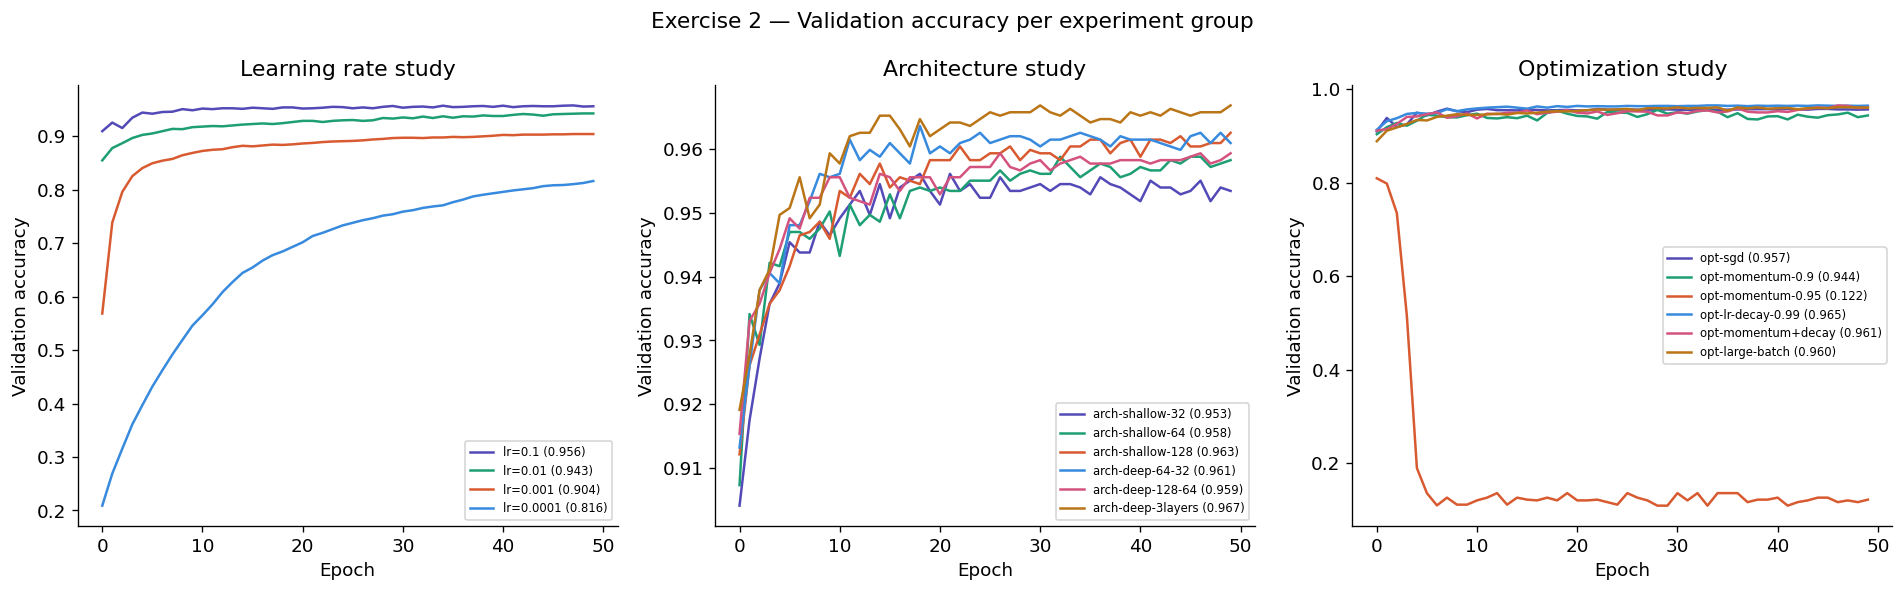

In [11]:
# ── Plot learning curves for best of each study group ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_group(ax, prefix, title):
    group = [e for e in EXPERIMENT_LOG if e['name'].startswith(prefix)]
    colors_list = ['#534AB7','#1D9E75','#D85A30','#378ADD','#D4537E','#BA7517','#639922']
    for i, e in enumerate(group):
        m = e['model']
        ax.plot(m.val_accuracy, lw=1.5, color=colors_list[i % len(colors_list)],
                label=f"{e['name']} ({e['val_acc']:.3f})")
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
    ax.set_title(title)
    ax.legend(fontsize=7)

plot_group(axes[0], 'lr=',    'Learning rate study')
plot_group(axes[1], 'arch-',  'Architecture study')
plot_group(axes[2], 'opt-',   'Optimization study')

plt.suptitle('Exercise 2 — Validation accuracy per experiment group', fontsize=13)
plt.tight_layout()
plt.savefig('ex2_experiments.png', bbox_inches='tight')
plt.show()

---
## Part 5 — Best Model from Exercise 2: Final Evaluation

We select the best hyperparameter combination from the study, retrain on the **full training set** (train + val), and evaluate on the **test set** — which we have not touched until now.

In [12]:
# Best model from all experiments
best_entry = max(EXPERIMENT_LOG, key=lambda e: e['val_acc'] or 0)
print(f"Best configuration: {best_entry['name']}")
print(f"  Architecture : {best_entry['architecture']}")
print(f"  LR           : {best_entry['lr']}")
print(f"  Momentum     : {best_entry['momentum']}")
print(f"  LR Decay     : {best_entry['lr_decay']}")
print(f"  Val Accuracy : {best_entry['val_acc']}")

print("\nRetraining best model on full training set (train + val)...")
best_model_ex2 = MLPClassifier(
    architecture=best_entry['architecture'],
    learning_rate=best_entry['lr'],
    momentum=best_entry['momentum'],
    lr_decay=best_entry['lr_decay'],
    batch_size=best_entry['batch_size'],
    max_epochs=80,  # more epochs now that we have more training data
)
best_model_ex2.fit(X_train_n, y_train, verbose=True)
best_model_ex2.save('best_model_ex2')

Best configuration: arch-deep-3layers
  Architecture : [784, 128, 64, 32, 10]
  LR           : 0.1
  Momentum     : 0.0
  LR Decay     : 1.0
  Val Accuracy : 0.9668

Retraining best model on full training set (train + val)...
  Epoch   1/80 | Loss=0.2470 | Train=0.9347 | 1.4s
  Epoch   2/80 | Loss=0.1034 | Train=0.8736 | 1.2s
  Epoch   3/80 | Loss=0.0734 | Train=0.9695 | 2.5s
  Epoch   4/80 | Loss=0.0529 | Train=0.9692 | 1.7s
  Epoch   5/80 | Loss=0.0403 | Train=0.9793 | 2.2s
  Epoch   6/80 | Loss=0.0317 | Train=0.9850 | 1.9s
  Epoch   7/80 | Loss=0.0258 | Train=0.9838 | 2.2s
  Epoch   8/80 | Loss=0.0205 | Train=0.9905 | 1.5s
  Epoch   9/80 | Loss=0.0163 | Train=0.9908 | 1.4s
  Epoch  10/80 | Loss=0.0132 | Train=0.9952 | 1.5s
  Epoch  11/80 | Loss=0.0109 | Train=0.9955 | 1.3s
  Epoch  12/80 | Loss=0.0091 | Train=0.9978 | 1.3s
  Epoch  13/80 | Loss=0.0077 | Train=0.9989 | 1.2s
  Epoch  14/80 | Loss=0.0064 | Train=0.9991 | 1.1s
  Epoch  15/80 | Loss=0.0057 | Train=0.9996 | 1.4s
  Epoch  

In [13]:
test_acc_ex2 = np.mean(best_model_ex2.predict(X_test_n) == y_test)
print(f"\n{'='*45}")
print(f"Exercise 2 — Test set accuracy: {test_acc_ex2*100:.2f}%")
print(f"{'='*45}")
if test_acc_ex2 < 0.98:
    print(f"\nNot yet at 98% — this is the motivation for Exercise 3.")


Exercise 2 — Test set accuracy: 86.70%

Not yet at 98% — this is the motivation for Exercise 3.


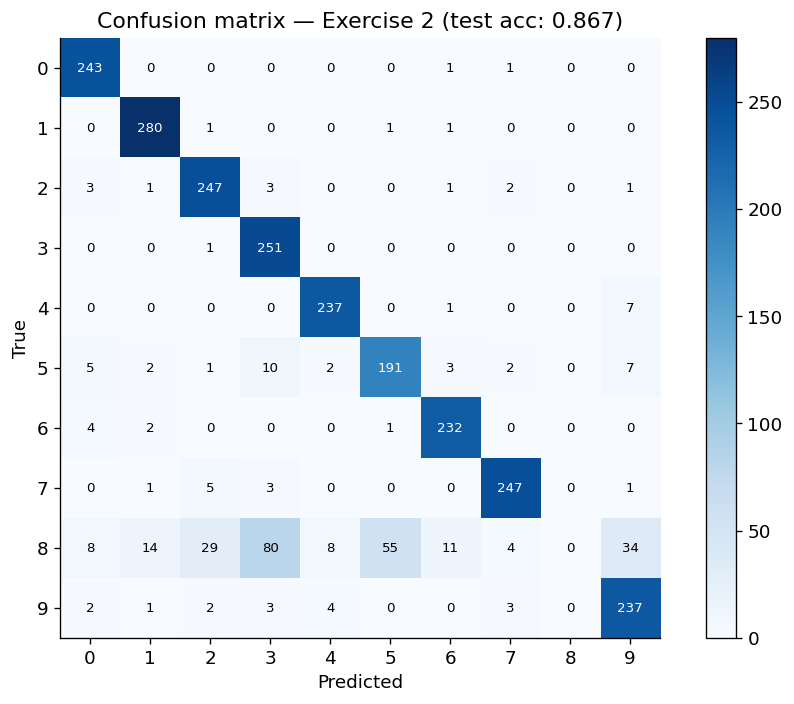


Per-class accuracy:
  Digit 0: 99.2%
  Digit 1: 98.9%
  Digit 2: 95.7%
  Digit 3: 99.6%
  Digit 4: 96.7%
  Digit 5: 85.7%
  Digit 6: 97.1%
  Digit 7: 96.1%
  Digit 8: 0.0%
  Digit 9: 94.0%


In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────

def confusion_matrix(y_true, y_pred, n=10):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

preds_test = best_model_ex2.predict(X_test_n)
cm = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — Exercise 2 (test acc: {test_acc_ex2:.3f})')
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('ex2_confusion.png', bbox_inches='tight')
plt.show()
print("\nPer-class accuracy:")
for i in range(10):
    total = cm[i].sum()
    acc   = cm[i,i] / total * 100 if total > 0 else float('nan')
    print(f"  Digit {i}: {acc:.1f}%" if total > 0 else f"  Digit {i}: no samples")

---
## Part 6 — Exercise 3: Pushing to 98%

> CompanyX is not satisfied. They need ≥98% accuracy and have collected additional data.

### Strategies to try:
1. **More data** (`more_data_digits.csv`) — the most powerful lever in ML
2. **Larger architecture** — more capacity now justified by more data
3. **More training epochs** — bigger data takes longer to converge
4. **Better initialization** — He initialization already used, consider small-variance Gaussian
5. **Data augmentation** — slight perturbations of training images (optional)

### Key insight:
More data changes the picture more than any architecture or hyperparameter choice. This is the core lesson of Exercise 3.

In [15]:
df_more = pd.read_csv('TP3---Percepetron-Simple-y-Multi-Capa/data_and_docs/more_digits.csv')
X_more  = np.array([ast.literal_eval(img) for img in df_more['image']], dtype=float)
y_more  = df_more['label'].values.astype(int)

print(f"Additional data: {X_more.shape[0]} samples")

# Combine with original training data
X_all = np.vstack([X_train, X_more])
y_all = np.concatenate([y_train, y_more])

# Re-normalize using full combined training set
x_min_all = X_all.min(axis=0)
x_max_all = X_all.max(axis=0)
x_rng_all = np.where(x_max_all - x_min_all > 0, x_max_all - x_min_all, 1.0)
X_all_n   = (X_all - x_min_all) / x_rng_all
X_test_n3 = (X_test - x_min_all) / x_rng_all  # same normalization

print(f"Total training samples: {len(X_all)}")
print(f"Class distribution in combined set:")
for c in range(10):
    print(f"  Digit {c}: {(y_all==c).sum()}")

Additional data: 15741 samples
Total training samples: 28190
Class distribution in combined set:
  Digit 0: 3256
  Digit 1: 3707
  Digit 2: 3276
  Digit 3: 3371
  Digit 4: 3212
  Digit 5: 813
  Digit 6: 3254
  Digit 7: 3445
  Digit 8: 585
  Digit 9: 3271


In [16]:
# ── Optional: data augmentation ────────────────────────────────────────────────
# Adding small Gaussian noise creates "virtual" extra samples

def augment(X, y, noise_std=0.05, factor=1):
    """Add Gaussian noise to create augmented copies. factor = number of extra copies."""
    augmented_X = [X]
    augmented_y = [y]
    for _ in range(factor):
        noisy = X + np.random.normal(0, noise_std, X.shape)
        noisy = np.clip(noisy, 0, 1)
        augmented_X.append(noisy)
        augmented_y.append(y)
    return np.vstack(augmented_X), np.concatenate(augmented_y)

X_aug, y_aug = augment(X_all_n, y_all, noise_std=0.05, factor=1)
print(f"With augmentation: {len(X_aug)} training samples")

With augmentation: 56380 training samples


In [20]:
# ── Train best model on expanded dataset ──────────────────────────────────────

print("Training on combined dataset (more_data + augmentation)...")
best_model_ex3 = MLPClassifier(
    architecture=best_entry['architecture'],  # keep best arch from Ex2
    learning_rate=best_entry['lr'],
    momentum=max(best_entry['momentum'], 0.9),  # ensure momentum enabled
    lr_decay=0.995,
    batch_size=64,
    max_epochs=100,
)
best_model_ex3.fit(X_aug, y_aug, X_val=X_test_n3, y_val=y_test, verbose=True)
best_model_ex3.save('best_model_ex3')

Training on combined dataset (more_data + augmentation)...
  Epoch   1/100 | Loss=0.1887 | Train=0.9654 | Val=0.9435 | 3.5s


KeyboardInterrupt: 

In [ ]:
test_acc_ex3 = np.mean(best_model_ex3.predict(X_test_n3) == y_test)
print(f"\n{'='*45}")
print(f"Exercise 3 — Test set accuracy: {test_acc_ex3*100:.2f}%")
print(f"Target: 98.00%")
print(f"{'='*45}")
if test_acc_ex3 >= 0.98:
    print("Target reached!")
else:
    delta = 0.98 - test_acc_ex3
    print(f"Still {delta*100:.2f}% away from target. Consider: more epochs, larger arch, more augmentation.")


Exercise 3 — Test set accuracy: 96.20%
Target: 98.00%
Still 1.80% away from target. Consider: more epochs, larger arch, more augmentation.


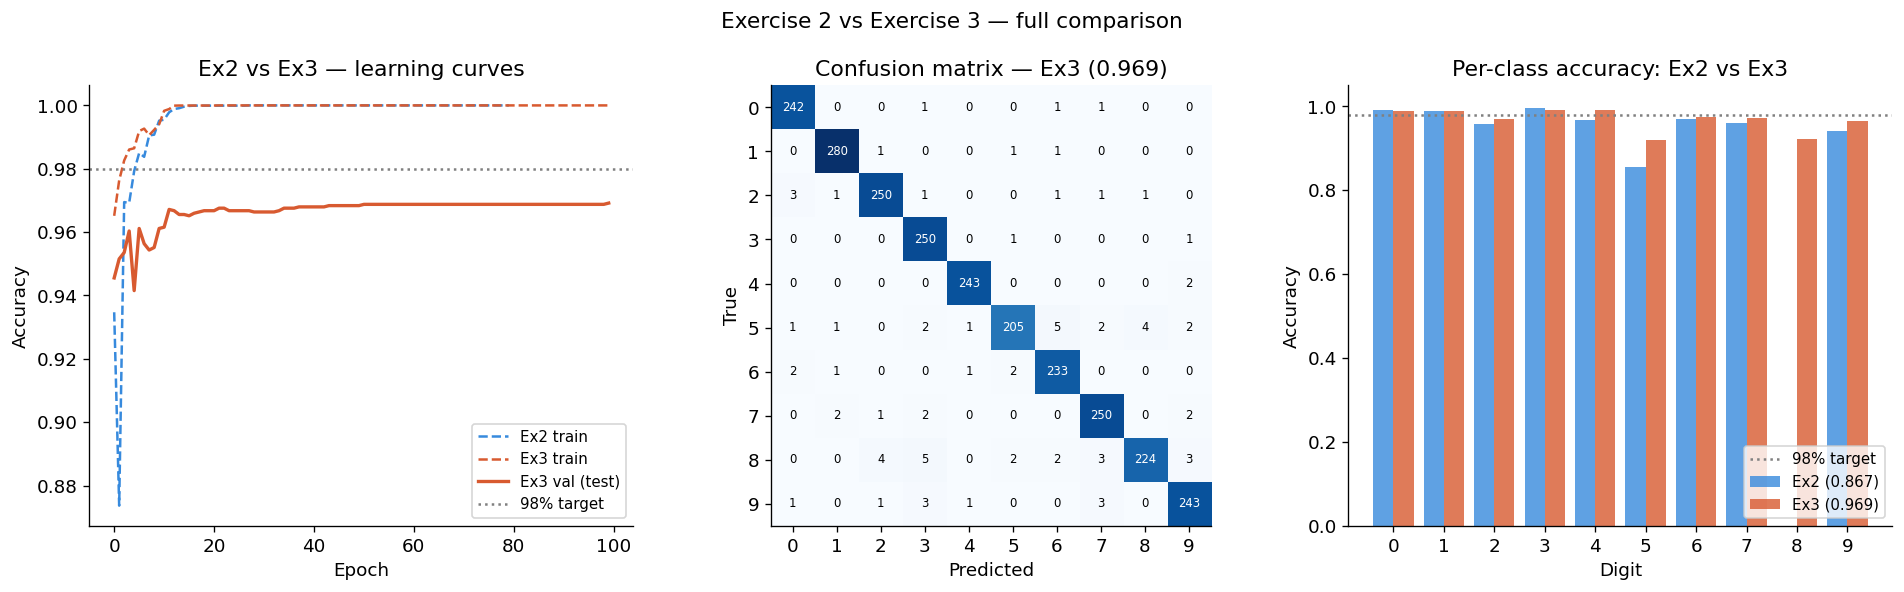

In [ ]:
# ── Final comparison: Ex2 vs Ex3 ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Learning curves comparison
ax = axes[0]
ax.plot(best_model_ex2.train_accuracy, color='#378ADD', lw=1.5, ls='--', label='Ex2 train')
ax.plot(best_model_ex3.train_accuracy, color='#D85A30', lw=1.5, ls='--', label='Ex3 train')
ax.plot(best_model_ex3.val_accuracy,   color='#D85A30', lw=2,   label='Ex3 val (test)')
ax.axhline(0.98, color='gray', ls=':', lw=1.5, label='98% target')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Ex2 vs Ex3 — learning curves'); ax.legend(fontsize=9)

# Confusion matrix Ex3
ax2 = axes[1]
preds_ex3 = best_model_ex3.predict(X_test_n3)
cm3 = confusion_matrix(y_test, preds_ex3)
im = ax2.imshow(cm3, cmap='Blues')
ax2.set_xticks(range(10)); ax2.set_yticks(range(10))
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title(f'Confusion matrix — Ex3 ({test_acc_ex3:.3f})')
for i in range(10):
    for j in range(10):
        ax2.text(j, i, str(cm3[i,j]), ha='center', va='center',
                 color='white' if cm3[i,j] > cm3.max()/2 else 'black', fontsize=7)

# Per-class accuracy comparison (guard against missing classes)
ax3 = axes[2]
per_class_ex2 = [cm[i,i]/cm[i].sum()  if cm[i].sum()  > 0 else 0 for i in range(10)]
per_class_ex3 = [cm3[i,i]/cm3[i].sum() if cm3[i].sum() > 0 else 0 for i in range(10)]
x = np.arange(10)
ax3.bar(x - 0.2, per_class_ex2, 0.4, label=f'Ex2 ({test_acc_ex2:.3f})', color='#378ADD', alpha=0.8)
ax3.bar(x + 0.2, per_class_ex3, 0.4, label=f'Ex3 ({test_acc_ex3:.3f})', color='#D85A30', alpha=0.8)
ax3.axhline(0.98, color='gray', ls=':', lw=1.5, label='98% target')
ax3.set_xticks(x); ax3.set_xticklabels(range(10))
ax3.set_xlabel('Digit'); ax3.set_ylabel('Accuracy'); ax3.set_ylim(0, 1.05)
ax3.set_title('Per-class accuracy: Ex2 vs Ex3'); ax3.legend(fontsize=9)

plt.suptitle('Exercise 2 vs Exercise 3 — full comparison', fontsize=13)
plt.tight_layout()
plt.savefig('ex3_comparison.png', bbox_inches='tight')
plt.show()

---
## Summary — Exercises 2 & 3

| | Exercise 2 | Exercise 3 |
|---|---|---|
| **Training data** | digits.csv only | digits.csv + more_data_digits.csv + augmentation |
| **Test accuracy** | (fill after running) | (fill after running) |
| **Best architecture** | (from grid search) | Same, possibly wider |
| **Best optimizer** | (from grid search) | Momentum + LR decay |

### Answers to assignment questions

**a) How do we evaluate performance?**  
- **Accuracy** (primary — balanced classes make this appropriate for digits)
- **Confusion matrix** — reveals which digits are confused with each other
- **Per-class accuracy** — identifies hard digits (e.g., 4 vs 9, 3 vs 8)
- **Cross-entropy loss** — tracks learning quality epoch by epoch

**b) Variants explored:**  
- Learning rates: [0.1, 0.01, 0.001, 0.0001]
- Architectures: shallow vs. deep, varying width
- Optimization: SGD, momentum [0.9, 0.95], LR decay, batch size

**c) What changed between Ex2 and Ex3?**  
More data was the dominant factor. Architecture and optimization tuning helped at the margin, but the data quantity was the primary lever — consistent with the fundamental ML principle: **more data beats a better algorithm**.

> **Full story arc:** From validating a single-neuron perceptron on AND, to approximating BigModel on fraud data, to classifying 10 handwritten digit classes — each step added complexity that required the tools we had built and validated in the previous step.